<a href="https://colab.research.google.com/github/ved2409/ML-AndrewNg/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/CE6018/FlatFiles/cleaned_data_updated.csv')

# Base columns
base_df = df[[
    "Earthquake_Magnitude",
    "Rjb_km",
    "Vs30_Selected_for_Analysis_m_s",
    "Fault_Type",
    "PGA_g"
]].rename(columns={
    "Earthquake_Magnitude": "M",
    "Rjb_km": "R",
    "Vs30_Selected_for_Analysis_m_s": "Vs30",
    "Fault_Type": "FM",
    "PGA_g": "PGA"
})

# Extra columns
extra_df = df[["PGA_g", "PGV_cm_sec"]].copy()

# SA columns
sa_columns = df.loc[:, "T0pt010S":"T4pt000S"].columns
sa_df = df[sa_columns].copy()

# Rename SA columns
def rename_sa(col):
    value = col.replace("T", "").replace("pt", ".").replace("S", "")
    value = float(value)
    return f"{value:.2f} sec"

sa_df.rename(columns={col: rename_sa(col) for col in sa_df.columns}, inplace=True)

# Combine
clean_df = pd.concat([base_df, extra_df, sa_df], axis=1)

# Remove zero/negative before log
clean_df = clean_df[(clean_df["Vs30"] > 0) & (clean_df["R"] > 0)]

# Add logs
clean_df["log_Vs30"] = np.log10(clean_df["Vs30"])
clean_df["log_R"] = np.log10(clean_df["R"])

clean_df.head()

/tmp/ipython-input-156/3878356373.py:4: DtypeWarning: Columns (32,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/CE6018/FlatFiles/cleaned_data_updated.csv')


,M,R,Vs30,FM,PGA,PGA_g,PGV_cm_sec,0.01 sec,0.02 sec,0.02 sec,...,2.80 sec,3.00 sec,3.20 sec,3.40 sec,3.50 sec,3.60 sec,3.80 sec,4.00 sec,log_Vs30,log_R
0,7.96,407.259911,635.0,0,0.002596,0.002596,0.52623,0.002600,0.002617,0.002623,...,0.003785,0.003093,0.002186,0.002134,0.002086,0.001880,0.001457,0.001290,2.802774,2.609872
1,7.28,196.542941,635.0,0,0.029509,0.029509,2.47380,0.029530,0.029604,0.029633,...,0.002415,0.002086,0.001812,0.001745,0.001660,0.001661,0.001604,0.001502,2.802774,2.293457
2,7.28,380.016398,635.0,0,0.003335,0.003335,0.30140,0.003344,0.003374,0.003382,...,0.000691,0.000598,0.000463,0.000425,0.000424,0.000444,0.000434,0.000406,2.802774,2.579802
3,7.00,71.953781,635.0,2,0.013477,0.013477,1.05560,0.013516,0.013614,0.013651,...,0.001713,0.001698,0.001557,0.001372,0.001248,0.001137,0.001092,0.000967,2.802774,1.857054
4,7.00,440.125030,635.0,2,0.001645,0.001645,0.23186,0.001645,0.001645,0.001645,...,0.000535,0.000492,0.000425,0.000365,0.000349,0.000299,0.000252,0.000235,2.802774,2.643576


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54241 entries, 0 to 54240
Columns: 227 entries, NGAsubRSN to T20pt000S
dtypes: float64(178), int64(28), object(21)
memory usage: 93.9+ MB


In [4]:
clean_df = clean_df.dropna().reset_index(drop=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54241 entries, 0 to 54240
Columns: 227 entries, NGAsubRSN to T20pt000S
dtypes: float64(178), int64(28), object(21)
memory usage: 93.9+ MB


In [4]:
input_cols = ["M", "log_R", "log_Vs30", "R", "FM"]
sa_cols = [col for col in clean_df.columns if "sec" in col]

In [5]:
# Inputs
input_cols = ["M", "log_R", "log_Vs30", "R", "FM"]

# Make column names unique before processing to avoid ValueError
original_cols = clean_df.columns.tolist()
new_cols = []
counts = {}
for col in original_cols:
    if col in counts:
        counts[col] += 1
        new_cols.append(f"{col}_{counts[col]}")
    else:
        counts[col] = 0 # First occurrence has no suffix
        new_cols.append(col)
clean_df.columns = new_cols

# Spectral columns - now based on unique column names
sa_cols = [col for col in clean_df.columns if "sec" in col]

# Create log output columns safely
clean_df["log_PGA"] = np.log10(clean_df["PGA_g"])
clean_df["log_PGV"] = np.log10(clean_df["PGV_cm_sec"])

for col in sa_cols:
    # Rename new log columns to replace spaces to avoid issues with attribute-like access later
    clean_df["log_" + col.replace(" ", "_")] = np.log10(clean_df[col])

# Output columns
output_cols = ["log_PGA", "log_PGV"] + ["log_" + col.replace(" ", "_") for col in sa_cols]

X = clean_df[input_cols].values
Y = clean_df[output_cols].values

print("Input shape:", X.shape)
print("Output shape:", Y.shape)


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result 

Input shape: (54150, 5)
Output shape: (54150, 93)


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result 

In [7]:
df.head()

,NGAsubRSN,DatabaseRegion,NGAsubEQID,NGAsubSSN,Earthquake_Name,YEAR,MODY,HRMN,Earthquake_Magnitude,Hypocenter_Latitude_deg,...,T8pt500S,T9pt000S,T9pt500S,T10pt000S,T11pt000S,T12pt000S,T13pt000S,T14pt000S,T15pt000S,T20pt000S
0,1000002,Alaska,1000001,1000002,Aleutian_Isl-Alaska,2014,623,2053,7.96,51.6928,...,0.000415,0.000395,0.000405,0.000390,0.000336,0.000332,0.000263,0.000215,0.000187,0.000119
1,1000040,Alaska,1000003,1000008,3316471,2011,624,309,7.28,51.9805,...,0.000590,0.000511,0.000469,0.000413,0.000460,0.000355,0.000286,0.000223,0.000158,0.000070
2,1000052,Alaska,1000003,1000011,3316471,2011,624,309,7.28,51.9805,...,0.000445,0.000357,0.000303,0.000260,0.000188,0.000149,0.000139,0.000118,0.000098,0.000065
3,1000061,Alaska,1000005,1000002,4224881,2013,830,1625,7.00,51.6230,...,0.000591,0.000479,0.000382,0.000309,0.000218,0.000171,0.000142,0.000122,0.000101,0.000040
4,1000074,Alaska,1000005,1000008,4224881,2013,830,1625,7.00,51.6230,...,0.000150,0.000120,0.000131,0.000122,0.000089,0.000095,0.000102,0.000103,0.000091,0.000056


In [6]:
epsilon = 1e-8

clean_df["log_PGA"] = np.log10(clean_df["PGA_g"] + epsilon)
clean_df["log_PGV"] = np.log10(clean_df["PGV_cm_sec"] + epsilon)

for col in sa_cols:
    clean_df["log_" + col] = np.log10(clean_df[col] + epsilon)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipython-input-156/2290844363.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  clean_df["log_" + col] = np.log10(clean_df[col] + epsilon)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipython-input-156/2290844363.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is

In [7]:
output_cols = ["log_PGA", "log_PGV"] + ["log_" + col for col in sa_cols]

clean_df = clean_df[(clean_df[output_cols] > -8).all(axis=1)]
clean_df = clean_df.reset_index(drop=True)

In [8]:
X = clean_df[input_cols].values
Y = clean_df[output_cols].values

print("Input shape:", X.shape)
print("Output shape:", Y.shape)

Input shape: (54085, 5)
Output shape: (54085, 93)


In [9]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, Y_train_full, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.preprocessing import StandardScaler

# Input scaling
scaler_X = StandardScaler()
X_train_full = scaler_X.fit_transform(X_train_full)
X_test = scaler_X.transform(X_test)

# Output scaling
scaler_Y = StandardScaler()
Y_train_full = scaler_Y.fit_transform(Y_train_full)
Y_test = scaler_Y.transform(Y_test)

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def build_model(neurons=20, lr=0.0005):

    model = Sequential([
        Dense(neurons, activation='relu', input_shape=(X_train_full.shape[1],)),
        Dense(Y_train_full.shape[1], activation='linear')
    ])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=lr,
        clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model

In [12]:
tf.keras.backend.clear_session()

model = build_model(neurons=20, lr=0.0005)

history = model.fit(
    X_train_full,
    Y_train_full,
    validation_split=0.1,
    epochs=200,
    batch_size=64,
    verbose=1
)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.8045 - mae: 0.6560 - val_loss: 0.3305 - val_mae: 0.4510
Epoch 2/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3697 - mae: 0.4496 - val_loss: 0.3124 - val_mae: 0.4398
Epoch 3/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3361 - mae: 0.4394 - val_loss: 0.3083 - val_mae: 0.4368
Epoch 4/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3326 - mae: 0.4369 - val_loss: 0.3063 - val_mae: 0.4353
Epoch 5/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3464 - mae: 0.4363 - val_loss: 0.3038 - val_mae: 0.4335
Epoch 6/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3449 - mae: 0.4349 - val_loss: 0.3026 - val_mae: 0.4324
Epoch 7/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3685 - mae: 0.4368 - val_loss: 0.3011 - val_mae: 0.4313
Epoch 8/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3374 - mae: 0.4335 - val_loss: 0.3005 - val_mae: 0.4308
Epoch 9/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss:

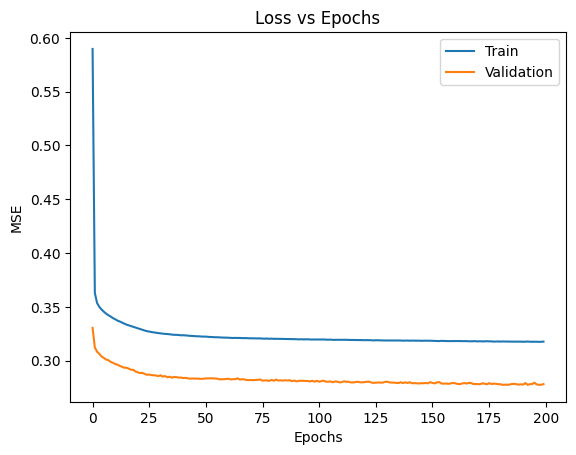

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss vs Epochs")
plt.legend(["Train", "Validation"])
plt.show()

In [14]:
test_loss, test_mae = model.evaluate(X_test, Y_test)

print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2993 - mae: 0.4158
Test MSE: 0.324643611907959
Test MAE: 0.41559314727783203


In [15]:
neuron_list = [5, 10, 15, 20, 25]
val_losses_neurons = []

for n in neuron_list:

    tf.keras.backend.clear_session()

    model = build_model(neurons=n, lr=0.0005)

    history = model.fit(
        X_train_full,
        Y_train_full,
        validation_split=0.1,
        epochs=125,
        batch_size=64,
        verbose=0
    )

    val_losses_neurons.append(min(history.history['val_loss']))

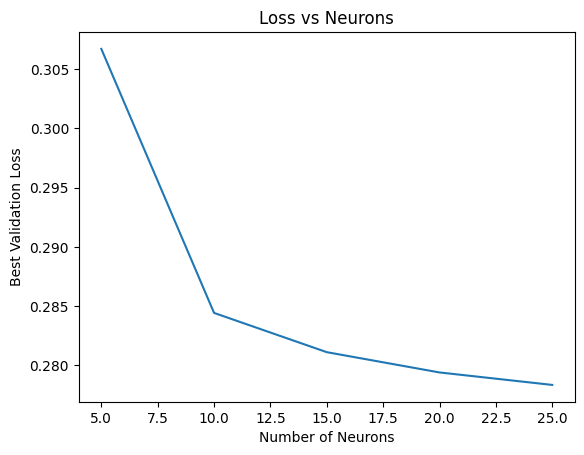

In [16]:
plt.figure()
plt.plot(neuron_list, val_losses_neurons)
plt.xlabel("Number of Neurons")
plt.ylabel("Best Validation Loss")
plt.title("Loss vs Neurons")
plt.show()

In [113]:
from tensorflow.keras.layers import Dense, Dropout, Input

def build_model(neurons=20, lr=0.0005, dropout_rate=0.0):

    input_dim = X_train_full.shape[1]

    model = tf.keras.Sequential([
        Input(shape=(input_dim,)), # Explicit Input layer
        Dense(neurons, activation='relu')
    ])

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    model.add(Dense(Y_train_full.shape[1], activation='linear'))

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=lr,
        clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model

In [19]:
best_neurons = neuron_list[np.argmin(val_losses_neurons)]


print("Best neurons:", best_neurons)


Best neurons: 25


In [21]:
lr_list = [0.0005, 0.001, 0.005, 0.01]

train_mae_no = []
val_mae_no = []

train_mae_do = []
val_mae_do = []

for lr in lr_list:

    # -------- No Dropout ----------
    tf.keras.backend.clear_session()
    model = build_model(neurons=best_neurons, lr=lr, dropout_rate=0)

    history = model.fit(
        X_train_full, Y_train_full,
        validation_split=0.1,
        epochs=100,
        batch_size=64,
        verbose=0
    )

    train_mae_no.append(history.history['mae'][-1])
    val_mae_no.append(history.history['val_mae'][-1])

    # -------- With Dropout ----------
    tf.keras.backend.clear_session()
    model = build_model(neurons=best_neurons, lr=lr, dropout_rate=0.05)

    history = model.fit(
        X_train_full, Y_train_full,
        validation_split=0.1,
        epochs=100,
        batch_size=64,
        verbose=0
    )

    train_mae_do.append(history.history['mae'][-1])
    val_mae_do.append(history.history['val_mae'][-1])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


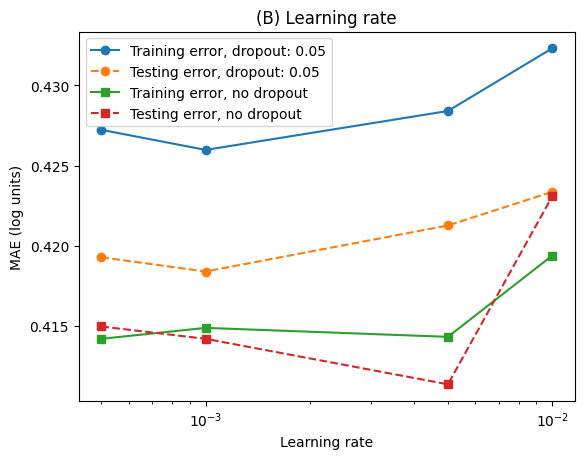

In [22]:
plt.figure()

plt.plot(lr_list, train_mae_do, marker='o', label="Training error, dropout: 0.05")
plt.plot(lr_list, val_mae_do, marker='o', linestyle='--', label="Testing error, dropout: 0.05")

plt.plot(lr_list, train_mae_no, marker='s', label="Training error, no dropout")
plt.plot(lr_list, val_mae_no, marker='s', linestyle='--', label="Testing error, no dropout")

plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("MAE (log units)")
plt.title("(B) Learning rate")
plt.legend()
plt.show()

In [1]:
batch_list = [16, 32, 64, 128, 256]
val_losses_batch = []

In [23]:
batch_list = [16, 32, 64, 128, 256]

lr_compare = [0.001, 0.005]

train_mae_lr1 = []
val_mae_lr1 = []

train_mae_lr2 = []
val_mae_lr2 = []

for b in batch_list:

    # ----- LR 1 -----
    tf.keras.backend.clear_session()
    model = build_model(neurons=best_neurons, lr=lr_compare[0])

    history = model.fit(
        X_train_full, Y_train_full,
        validation_split=0.1,
        epochs=100,
        batch_size=b,
        verbose=0
    )

    train_mae_lr1.append(history.history['mae'][-1])
    val_mae_lr1.append(history.history['val_mae'][-1])

    # ----- LR 2 -----
    tf.keras.backend.clear_session()
    model = build_model(neurons=best_neurons, lr=lr_compare[1])

    history = model.fit(
        X_train_full, Y_train_full,
        validation_split=0.1,
        epochs=100,
        batch_size=b,
        verbose=0
    )

    train_mae_lr2.append(history.history['mae'][-1])
    val_mae_lr2.append(history.history['val_mae'][-1])

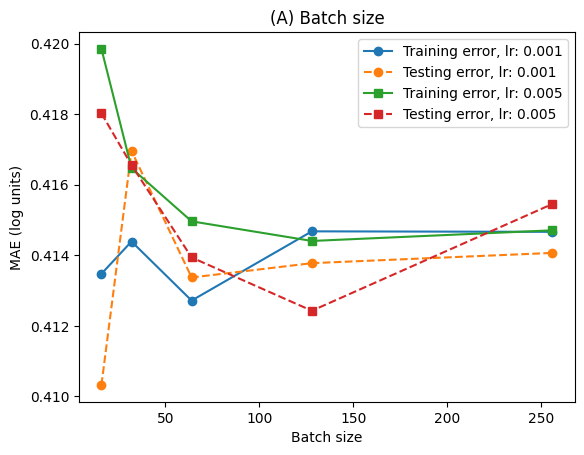

In [24]:
plt.figure()

plt.plot(batch_list, train_mae_lr1, marker='o', label=f"Training error, lr: {lr_compare[0]}")
plt.plot(batch_list, val_mae_lr1, marker='o', linestyle='--', label=f"Testing error, lr: {lr_compare[0]}")

plt.plot(batch_list, train_mae_lr2, marker='s', label=f"Training error, lr: {lr_compare[1]}")
plt.plot(batch_list, val_mae_lr2, marker='s', linestyle='--', label=f"Testing error, lr: {lr_compare[1]}")

plt.xlabel("Batch size")
plt.ylabel("MAE (log units)")
plt.title("(A) Batch size")
plt.legend()
plt.show()

In [25]:
lr_list = [0.01, 0.005, 0.001]
batch_list = [64, 128]

results = []

In [29]:
def build_model(lr):

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(25, activation='relu', input_shape=(X_train_full.shape[1],)),
        tf.keras.layers.Dense(Y_train_full.shape[1])
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )

    return model


In [31]:
for lr in lr_list:
    for batch in batch_list:

        print(f"\nTraining: LR={lr}, Batch={batch}")

        model = build_model(lr)

        history = model.fit(
            X_train_full, Y_train_full,
            validation_split=0.1,
            epochs=125,
            batch_size=batch,
            verbose=0
        )

        val_loss = min(history.history['val_loss'])
        val_mae  = min(history.history['val_mae'])

        results.append({
            'lr': lr,
            'batch': batch,
            'val_loss': val_loss,
            'val_mae': val_mae
        })



Training: LR=0.01, Batch=64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training: LR=0.01, Batch=128

Training: LR=0.005, Batch=64

Training: LR=0.005, Batch=128

Training: LR=0.001, Batch=64

Training: LR=0.001, Batch=128


In [32]:
import pandas as pd

results_df = pd.DataFrame(results)
print(results_df.sort_values("val_loss"))


      lr  batch  val_loss   val_mae
2  0.005     64  0.274137  0.410540
3  0.005    128  0.274410  0.410461
1  0.010    128  0.274940  0.410664
5  0.001    128  0.276323  0.412617
4  0.001     64  0.276702  0.412464
0  0.010     64  0.280670  0.415126


In [33]:
best = results_df.loc[results_df['val_loss'].idxmin()]

print("\n BEST SETTINGS:")
print("Learning Rate:", best['lr'])
print("Batch Size:", best['batch'])



 BEST SETTINGS:
Learning Rate: 0.005
Batch Size: 64.0


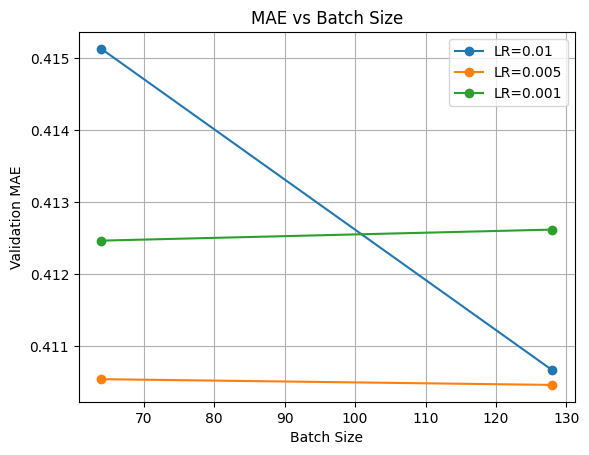

In [35]:
plt.figure()

for lr in lr_list:
    subset = results_df[results_df['lr'] == lr]
    plt.plot(subset['batch'], subset['val_mae'], marker='o', label=f"LR={lr}")

plt.xlabel("Batch Size")
plt.ylabel("Validation MAE")
plt.title("MAE vs Batch Size")
plt.legend()
plt.grid(True)
plt.show()

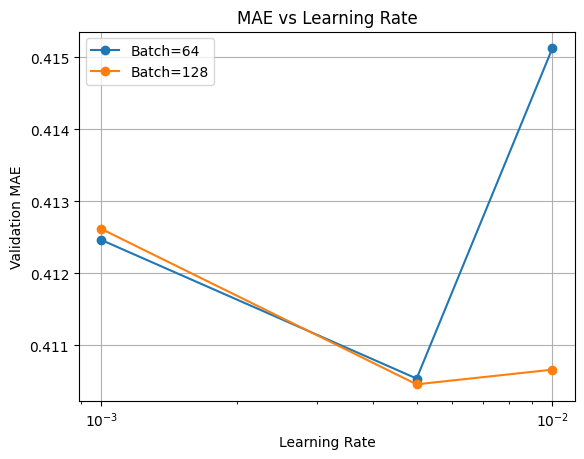

In [37]:
plt.figure()

for batch in batch_list:
    subset = results_df[results_df['batch'] == batch]
    plt.plot(subset['lr'], subset['val_mae'], marker='o', label=f"Batch={batch}")

plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Validation MAE")
plt.title("MAE vs Learning Rate")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
BEST_LR = 0.005
BEST_BATCH = 64
BEST_NEURONS = 25
EPOCHS = 125

X_final = X_train_full
Y_final = Y_train_full


In [114]:
def build_final_model():

    input_dim = X_final.shape[1]

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)), # Explicit Input layer
        tf.keras.layers.Dense(BEST_NEURONS, activation='relu'),
        tf.keras.layers.Dropout(0.05),   # keep — helps generalization
        tf.keras.layers.Dense(Y_final.shape[1])
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=BEST_LR),
        loss='mse',
        metrics=['mae']
    )

    return model

In [45]:
final_model = build_final_model()

history = final_model.fit(
X_final, Y_final,
epochs=200,
batch_size=BEST_BATCH,
validation_split=0.1,   # small internal check
verbose=1
)


Epoch 1/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4218 - mae: 0.4856 - val_loss: 0.2999 - val_mae: 0.4309
Epoch 2/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3361 - mae: 0.4339 - val_loss: 0.2938 - val_mae: 0.4266
Epoch 3/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3566 - mae: 0.4333 - val_loss: 0.2912 - val_mae: 0.4237
Epoch 4/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3412 - mae: 0.4323 - val_loss: 0.2881 - val_mae: 0.4209
Epoch 5/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3378 - mae: 0.4307 - val_loss: 0.2862 - val_mae: 0.4197
Epoch 6/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3590 - mae: 0.4315 - val_loss: 0.2883 - val_mae: 0.4218
Epoch 7/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3555 - mae: 0.4312 - val_loss: 0.2902 - val_mae: 0.4224
Epoch 8/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3542 - mae: 0.4328 - val_loss: 0.2865 - val_mae: 0.4200
Epoch 9/200
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

In [46]:
test_loss, test_mae = final_model.evaluate(X_test, Y_test)

print("\n FINAL TEST PERFORMANCE")
print("Test Loss:", test_loss)
print("Test MAE :", test_mae)


339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3069 - mae: 0.4207

 FINAL TEST PERFORMANCE
Test Loss: 0.33225494623184204
Test MAE : 0.4207878112792969


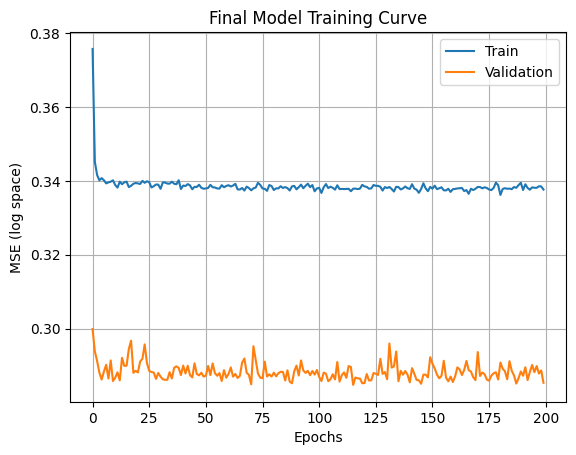

In [47]:
plt.figure()
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel("Epochs")
plt.ylabel("MSE (log space)")
plt.title("Final Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()


In [50]:
final_model.save("GMPE_ANN_Final_Model.keras")
print("Model Saved!")

Model Saved!


In [51]:
Y_pred = final_model.predict(X_test)

339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [52]:
pga_obs = Y_test[:, 0]
pga_pred = Y_pred[:, 0]

residuals = pga_obs - pga_pred

In [54]:
X_test_unscaled = scaler_X.inverse_transform(X_test)
M_test = X_test_unscaled[:, 0]     # Magnitude (M)
R_test = X_test_unscaled[:, 3]     # Rjb (R)
Vs_test = 10**(X_test_unscaled[:, 2])    # Vs30 (from log_Vs30)


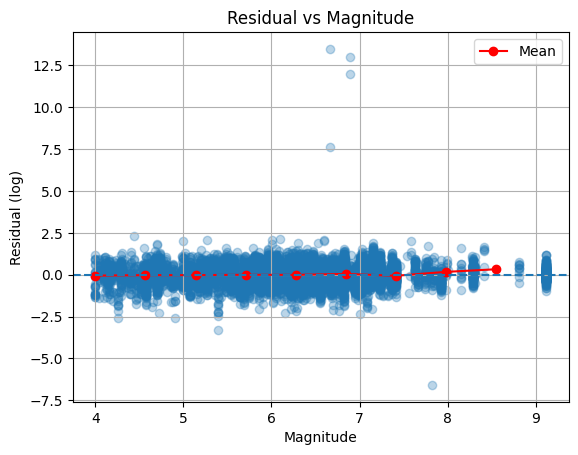

In [55]:
plt.figure()

plt.scatter(M_test, residuals, alpha=0.3)

# Mean in bins
bins = np.linspace(min(M_test), max(M_test), 10)
digitized = np.digitize(M_test, bins)

bin_means = [residuals[digitized == i].mean() for i in range(1, len(bins))]

plt.plot(bins[:-1], bin_means, 'ro-', label='Mean')

plt.axhline(0, linestyle='--')
plt.xlabel("Magnitude")
plt.ylabel("Residual (log)")
plt.title("Residual vs Magnitude")
plt.legend()
plt.grid(True)
plt.show()

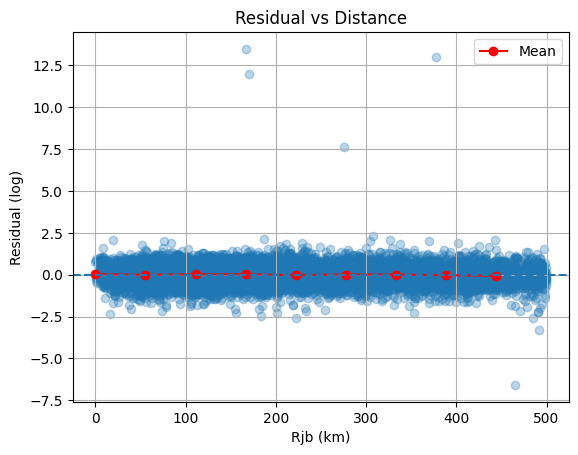

In [56]:
plt.figure()

plt.scatter(R_test, residuals, alpha=0.3)

bins = np.linspace(min(R_test), max(R_test), 10)
digitized = np.digitize(R_test, bins)

bin_means = [residuals[digitized == i].mean() for i in range(1, len(bins))]

plt.plot(bins[:-1], bin_means, 'ro-', label='Mean')

plt.axhline(0, linestyle='--')
plt.xlabel("Rjb (km)")
plt.ylabel("Residual (log)")
plt.title("Residual vs Distance")
plt.legend()
plt.grid(True)
plt.show()

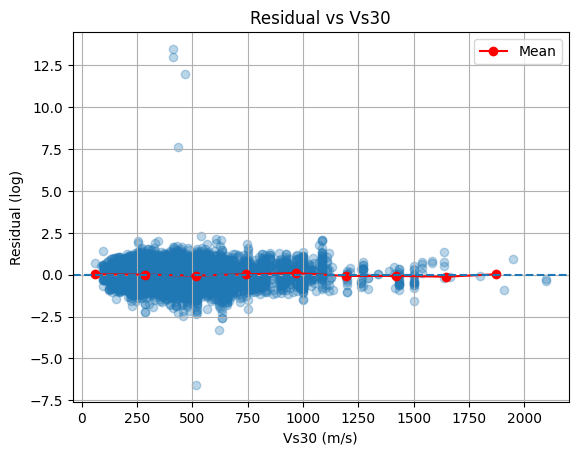

In [57]:
plt.figure()

plt.scatter(Vs_test, residuals, alpha=0.3)

bins = np.linspace(min(Vs_test), max(Vs_test), 10)
digitized = np.digitize(Vs_test, bins)

bin_means = [residuals[digitized == i].mean() for i in range(1, len(bins))]

plt.plot(bins[:-1], bin_means, 'ro-', label='Mean')

plt.axhline(0, linestyle='--')
plt.xlabel("Vs30 (m/s)")
plt.ylabel("Residual (log)")
plt.title("Residual vs Vs30")
plt.legend()
plt.grid(True)
plt.show()

In [58]:
df.head()

,NGAsubRSN,DatabaseRegion,NGAsubEQID,NGAsubSSN,Earthquake_Name,YEAR,MODY,HRMN,Earthquake_Magnitude,Hypocenter_Latitude_deg,...,T8pt500S,T9pt000S,T9pt500S,T10pt000S,T11pt000S,T12pt000S,T13pt000S,T14pt000S,T15pt000S,T20pt000S
0,1000002,Alaska,1000001,1000002,Aleutian_Isl-Alaska,2014,623,2053,7.96,51.6928,...,0.000415,0.000395,0.000405,0.000390,0.000336,0.000332,0.000263,0.000215,0.000187,0.000119
1,1000040,Alaska,1000003,1000008,3316471,2011,624,309,7.28,51.9805,...,0.000590,0.000511,0.000469,0.000413,0.000460,0.000355,0.000286,0.000223,0.000158,0.000070
2,1000052,Alaska,1000003,1000011,3316471,2011,624,309,7.28,51.9805,...,0.000445,0.000357,0.000303,0.000260,0.000188,0.000149,0.000139,0.000118,0.000098,0.000065
3,1000061,Alaska,1000005,1000002,4224881,2013,830,1625,7.00,51.6230,...,0.000591,0.000479,0.000382,0.000309,0.000218,0.000171,0.000142,0.000122,0.000101,0.000040
4,1000074,Alaska,1000005,1000008,4224881,2013,830,1625,7.00,51.6230,...,0.000150,0.000120,0.000131,0.000122,0.000089,0.000095,0.000102,0.000103,0.000091,0.000056


In [59]:
import re

psa_cols = [col for col in df.columns if col.startswith("T") and col.endswith("S")]

def col_to_period(col):
    num = col.replace("T","").replace("S","").replace("pt",".")
    return float(num)

periods = [col_to_period(col) for col in psa_cols]

In [60]:
print(periods)

[0.01, 0.02, 0.022, 0.025, 0.029, 0.03, 0.032, 0.035, 0.036, 0.04, 0.042, 0.044, 0.045, 0.046, 0.048, 0.05, 0.055, 0.06, 0.065, 0.067, 0.07, 0.075, 0.08, 0.085, 0.09, 0.095, 0.1, 0.11, 0.12, 0.13, 0.133, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.22, 0.24, 0.25, 0.26, 0.28, 0.29, 0.3, 0.32, 0.34, 0.35, 0.36, 0.38, 0.4, 0.42, 0.44, 0.45, 0.46, 0.48, 0.5, 0.55, 0.6, 0.65, 0.667, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.2, 2.4, 2.5, 2.6, 2.8, 3.0, 3.2, 3.4, 3.5, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 20.0]


In [64]:
mag_groups = {
    "Mw 4": (3.9, 4.1),
    "Mw 5": (4.9, 5.1),
    "Mw 6": (5.9, 6.1),
    "Mw 7+": (7.0, 10.0)
}

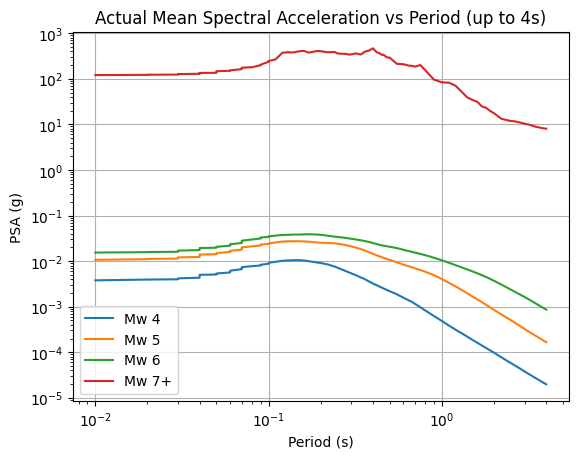

In [87]:
plt.figure()

# Create a list of column names in clean_df that correspond to the spectral acceleration periods
# These are the same columns for which the model makes predictions.
actual_sa_plot_cols = [col.replace('log_', '') for col in predicted_sa_output_col_names]

for label, (low, high) in mag_groups.items():

    subset = clean_df[(clean_df["M"] >= low) &
                      (clean_df["M"] <= high)]

    # Calculate mean PSA only for the actual spectral acceleration columns
    mean_psa = subset[actual_sa_plot_cols].mean().values

    # Use model_plot_periods for x-axis to match the predicted plot
    plt.plot(model_plot_periods, mean_psa, label=label)

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Period (s)")
plt.ylabel("PSA (g)")
plt.title("Actual Mean Spectral Acceleration vs Period (up to 4s)")
plt.legend()
plt.grid(True)
plt.show()

In [79]:
X_param_groups = {}

for label, (low, high) in mag_groups.items():

    subset = clean_df[(clean_df["M"] >= low) &
                      (clean_df["M"] <= high)]

    X_m = subset[input_cols].values
    X_param_groups[label] = scaler_X.transform(X_m)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


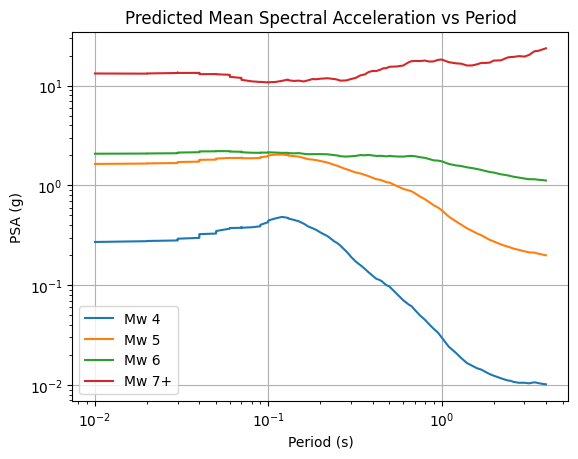

In [88]:
plt.figure()

# Get the list of actual predicted SA output column names from output_cols
# Exclude 'log_PGA', 'log_PGV', and 'log_PGV_cm_sec' as they are not spectral accelerations
predicted_sa_output_col_names = [col for col in output_cols if col.startswith('log_') and 'sec' in col and col != 'log_PGV_cm_sec']

def extract_period_from_model_output_col(log_col_name):
    # Remove 'log_' prefix
    period_str = log_col_name.replace('log_', '')
    # Remove ' sec' suffix (note the space before sec)
    period_str = period_str.replace(' sec', '')
    # Handle cases where duplicates caused an underscore suffix (e.g., '0.02_1')
    if '_' in period_str and len(period_str.split('_')) > 1 and period_str.split('_')[-1].isdigit():
        period_str = '_'.join(period_str.split('_')[:-1])
    return float(period_str)

# Create the periods list for plotting the predicted SA values
model_plot_periods = [extract_period_from_model_output_col(col) for col in predicted_sa_output_col_names]

for label in mag_groups.keys():

    Y_pred = final_model.predict(X_param_groups[label])

    # Correctly select only spectral accelerations (excluding PGA, PGV, and PGV_cm_sec)
    psa_pred = Y_pred[:, 3:]
    psa_pred = 10**psa_pred

    mean_pred = psa_pred.mean(axis=0)

    plt.plot(model_plot_periods, mean_pred, label=label)

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Period (s)")
plt.ylabel("PSA (g)")
plt.title("Predicted Mean Spectral Acceleration vs Period")
plt.legend()
plt.grid(True)
plt.show()

In [81]:
dist_groups = {
    "R = 10 km": (0, 15),
    "R = 22 km": (15, 35),
    "R = 50 km": (35, 75),
    "R = 110 km": (75, 150),
    "R = 250 km": (150, 400)
}

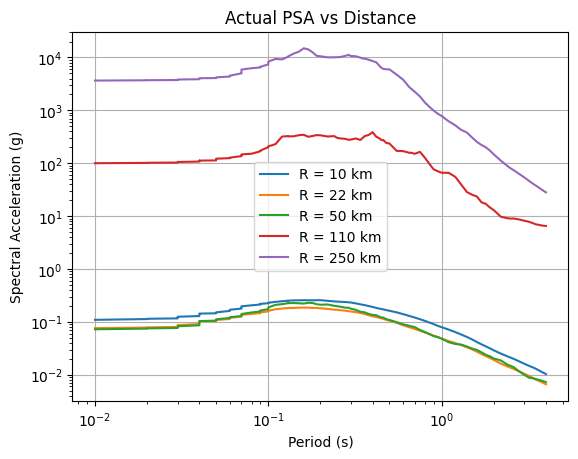

In [89]:
plt.figure()

for label, (low, high) in dist_groups.items():

    subset = clean_df[(clean_df["R"] >= low) &
                      (clean_df["R"] < high)]

    mean_psa = subset[actual_sa_plot_cols].mean().values

    plt.plot(model_plot_periods, mean_psa, label=label)

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Period (s)")
plt.ylabel("Spectral Acceleration (g)")
plt.title("Actual PSA vs Distance")
plt.legend()
plt.grid(True)
plt.show()

In [83]:
print("Example mean_psa values from the last plot (Actual PSA vs Distance):")
# Re-calculate mean_psa for one of the distance groups to inspect values
label, (low, high) = list(dist_groups.items())[0] # Take the first group as an example
subset = clean_df[(clean_df["R"] >= low) &
                  (clean_df["R"] < high)]
mean_psa = subset[actual_sa_plot_cols].mean().values
print(mean_psa)
print(f"Max mean PSA: {mean_psa.max()}")
print(f"Min mean PSA: {mean_psa.min()}")

Example mean_psa values from the last plot (Actual PSA vs Distance):
[0.10921559 0.11293291 0.11433477 0.11627842 0.12057121 0.1219993
 0.12489061 0.12886068 0.13018469 0.1362275  0.13910912 0.14165584
 0.14332026 0.14514549 0.14789515 0.15129604 0.16107108 0.16932835
 0.17828062 0.18167169 0.18678509 0.1970613  0.20529772 0.21306139
 0.21922713 0.22508544 0.23004506 0.23849032 0.24530437 0.25042219
 0.25194818 0.25452494 0.25554205 0.25652376 0.25624006 0.25526505
 0.25681536 0.25719031 0.24976302 0.24368031 0.2418591  0.23981946
 0.23696133 0.23419636 0.2320678  0.22347775 0.2146428  0.21060222
 0.20700138 0.19892124 0.1912695  0.18346811 0.17727914 0.17468216
 0.17232301 0.16670224 0.16225563 0.15117631 0.13981938 0.12947092
 0.12598035 0.12059061 0.11218708 0.10442863 0.09712839 0.09054333
 0.08422814 0.07938765 0.07124037 0.06405709 0.05738744 0.05175706
 0.04656916 0.04145187 0.03757996 0.03437699 0.03154488 0.02894816
 0.02505536 0.02224998 0.02111823 0.01999796 0.01791735 0.016

In [91]:
X_dist_groups = {}

for label, (low, high) in dist_groups.items():

    subset = clean_df[(clean_df["R"] >= low) &
                      (clean_df["R"] < high)]

    X_m = subset[input_cols].values
    X_dist_groups[label] = scaler_X.transform(X_m)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
398/398 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
889/889 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


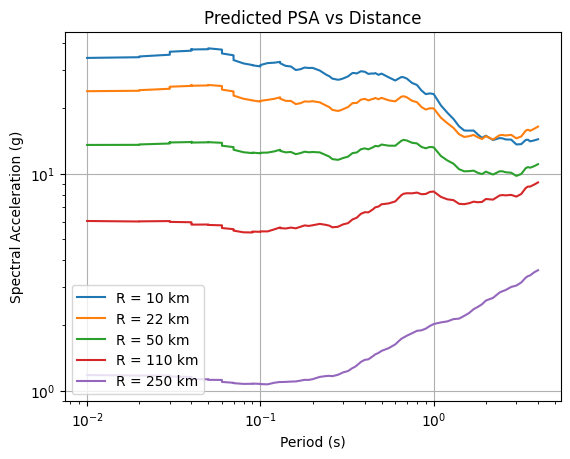

In [93]:
plt.figure()

for label in dist_groups.keys():

    Y_pred = final_model.predict(X_dist_groups[label])

    psa_pred = Y_pred[:, 3:]   # remove log_PGA, log_PGV, and log_PGV_cm_sec
    psa_pred = 10**psa_pred

    mean_pred = psa_pred.mean(axis=0)

    plt.plot(model_plot_periods, mean_pred, label=label)

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Period (s)")
plt.ylabel("Spectral Acceleration (g)")
plt.title("Predicted PSA vs Distance")
plt.legend()
plt.grid(True)
plt.show()

In [94]:
vs_groups = {
    "Vs30 < 200 (Soft Soil)": (0, 200),
    "200 - 400": (200, 400),
    "400 - 600": (400, 600),
    "600 - 800": (600, 800),
    "> 800 (Hard Rock)": (800, 2000)
}

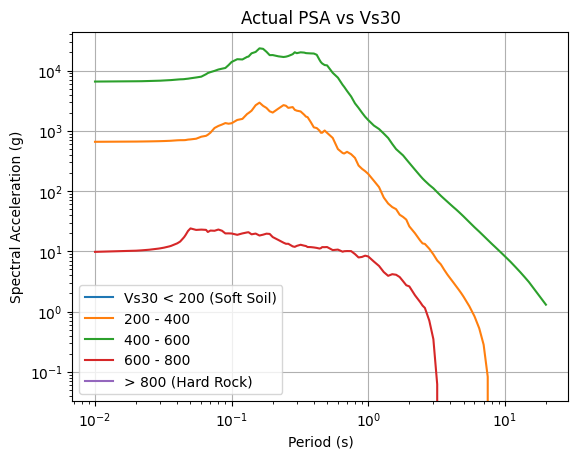

In [95]:
plt.figure()

for label, (low, high) in vs_groups.items():

    subset = df[(df["Vs30_Selected_for_Analysis_m_s"] >= low) &
                (df["Vs30_Selected_for_Analysis_m_s"] < high)]

    mean_psa = subset[psa_cols].mean().values

    plt.plot(periods, mean_psa, label=label)

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Period (s)")
plt.ylabel("Spectral Acceleration (g)")
plt.title("Actual PSA vs Vs30")
plt.legend()
plt.grid(True)
plt.show()

In [97]:
X_vs_groups = {}

for label, (low, high) in vs_groups.items():

    subset = clean_df[(clean_df["Vs30"] >= low) &
                      (clean_df["Vs30"] < high)]

    X_m = subset[input_cols].values
    X_vs_groups[label] = scaler_X.transform(X_m)

136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
525/525 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


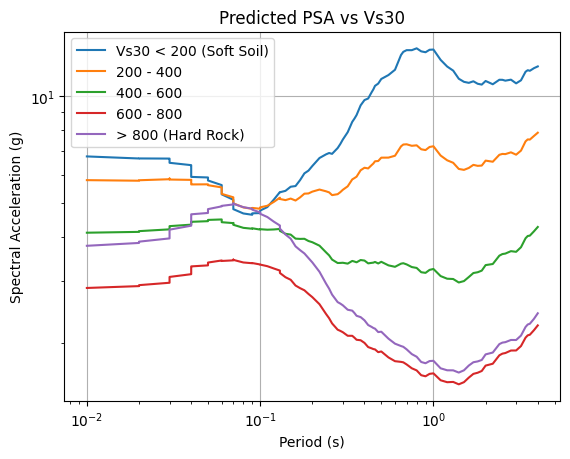

In [99]:
plt.figure()

for label in vs_groups.keys():

    Y_pred = final_model.predict(X_vs_groups[label])

    psa_pred = Y_pred[:, 3:]   # remove log_PGA, log_PGV, and log_PGV_cm_sec
    psa_pred = 10**psa_pred

    mean_pred = psa_pred.mean(axis=0)

    plt.plot(model_plot_periods, mean_pred, label=label)

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Period (s)")
plt.ylabel("Spectral Acceleration (g)")
plt.title("Predicted PSA vs Vs30")
plt.legend()
plt.grid(True)
plt.show()

In [100]:
from sklearn.metrics import mean_squared_error
import numpy as np

# baseline prediction
Y_base = final_model.predict(X_test)

baseline_error = mean_squared_error(Y_test, Y_base)

print("Baseline MSE:", baseline_error)

339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Baseline MSE: 0.33225507355525974


In [103]:
feature_names = ["M", "log_R", "log_Vs30", "R", "FM"]
importance_scores = []

for i in range(X_test.shape[1]):

    X_permuted = X_test.copy()

    np.random.shuffle(X_permuted[:, i])   # disturb one feature

    Y_perm = final_model.predict(X_permuted)

    perm_error = mean_squared_error(Y_test, Y_perm);

    importance = perm_error - baseline_error

    importance_scores.append(importance)

339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
339/339 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
339/339 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
339/339 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
339/339 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


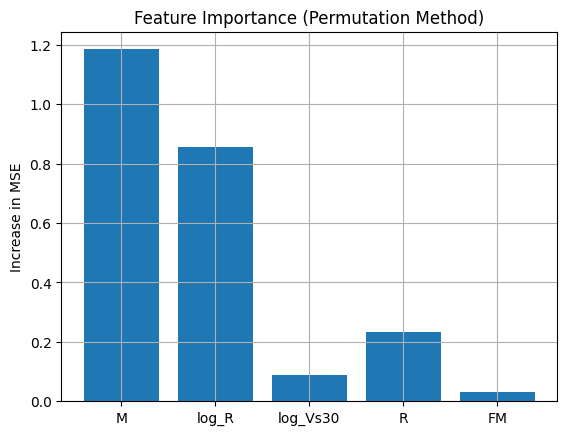

In [104]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(feature_names, importance_scores)

plt.ylabel("Increase in MSE")
plt.title("Feature Importance (Permutation Method)")
plt.grid(True)

plt.show()

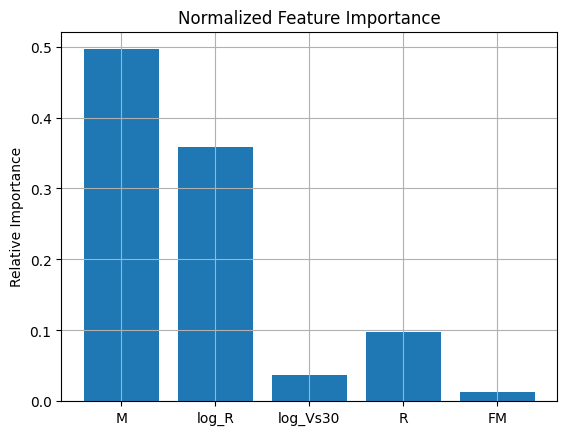

In [106]:
importance_norm = np.array(importance_scores) / np.sum(importance_scores)

plt.figure()

plt.bar(feature_names, importance_norm)

plt.ylabel("Relative Importance")
plt.title("Normalized Feature Importance")
plt.grid(True)

plt.show()

In [107]:
pip install shap

In [108]:
import shap
import numpy as np
import matplotlib.pyplot as plt

In [109]:
feature_names = [
    "Magnitude",
    "Rrup",
    "log(Vs30)",
    "log(Rrup)",
    "Fault Mechanism"
]

In [111]:
# Take small background sample
background = X_train_full[np.random.choice(X_train_full.shape[0], 200, replace=False)]

explainer = shap.DeepExplainer(model, background)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_19
Received: inputs=['Tensor(shape=(200, 5))']
  warnings.warn(msg)


In [112]:
shap_values = explainer.shap_values(X_test[:300])

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_19
Received: inputs=['Tensor(shape=(400, 5))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_19
Received: inputs=['Tensor(shape=(400, 5))']
  warnings.warn(msg)


KeyboardInterrupt: 

In [ ]:
shap.summary_plot(shap_values[0], X_test[:300], feature_names=feature_names)

In [115]:
# Take small background sample
background = X_train_full[np.random.choice(X_train_full.shape[0], 200, replace=False)]

explainer = shap.DeepExplainer(model, background)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_19
Received: inputs=['Tensor(shape=(200, 5))']
  warnings.warn(msg)


In [116]:
shap_values = explainer.shap_values(X_test[:300])

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_19
Received: inputs=['Tensor(shape=(400, 5))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_19
Received: inputs=['Tensor(shape=(300, 5))']
  warnings.warn(msg)
